# Bayesian inference on the Planck 2018 binned TT power spectrum

**Final project — Advanced data & statistical methods lab.**
Reproducible notebook (Option 1: companion to the LaTeX report).

We fit the publicly released Planck 2018 *binned* TT angular power spectrum with
a CAMB-based theoretical model and a simplified per-bin Gaussian likelihood,
sampled with MCMC.

The compute engine (data loading, CAMB theory, priors and likelihood) lives in
the module **`planck_model.py`**. Keeping it in a module — rather than inline —
is what lets the MCMC worker processes import it under the `spawn` start method,
which is required on macOS and avoids the OpenMP + `fork` deadlock.

---
## Step 1 — Setup & data loading

In [1]:
# Step 1: imports and configuration
import os, sys
# one thread per process; set before importing numpy/camb (also done inside the module)
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"
sys.path.insert(0, os.getcwd())          # make planck_model importable (incl. spawn workers)

import numpy as np
import matplotlib.pyplot as plt
import planck_model as pm                 # loads the data and defines the model on import

FIG_DIR, CHAIN_DIR = "figures", "chains"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(CHAIN_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# handy local aliases
ell, Dl, err = pm.ell, pm.Dl, pm.err
theory_dl, log_posterior = pm.theory_dl, pm.log_posterior
NDIM, theta_fid = pm.NDIM, pm.theta_fid
print(f"{len(ell)} bins, ell range {ell.min():.0f}-{ell.max():.0f}")

83 bins, ell range 48-2499


### The Planck 2018 binned TT spectrum
`planck_model.py` downloads `COM_PowerSpect_CMB-TT-binned_R3.01.txt` (Planck PR3
ancillary data) once and caches it. Five columns: effective multipole $\ell$,
bandpower $D_\ell=\ell(\ell+1)C_\ell/2\pi\;[\mu K^2]$, lower/upper $1\sigma$
errors, and the Planck best fit.

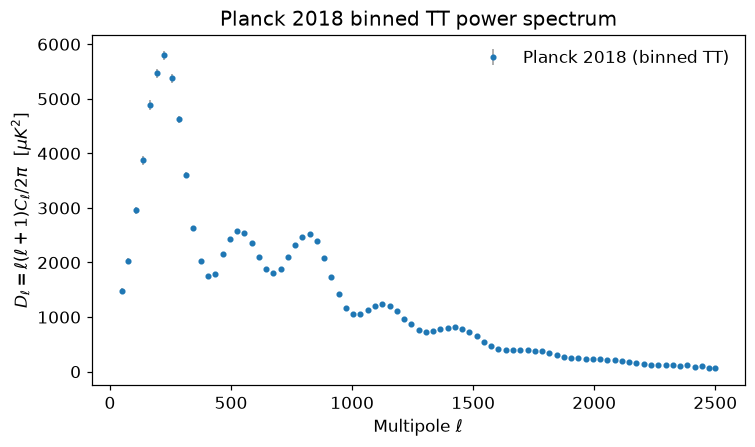

In [2]:
# Step 1: plot the data with error bars
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ell, Dl, yerr=err, fmt="o", ms=3, lw=1,
            color="C0", ecolor="0.6", label="Planck 2018 (binned TT)")
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell=\ell(\ell+1)C_\ell/2\pi\ \ [\mu K^2]$")
ax.set_title("Planck 2018 binned TT power spectrum")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "planck_tt_data.pdf")); plt.show()

---
## Step 2 — Theoretical model with CAMB
`pm.theory_dl(theta)` returns the lensed $D_\ell^{TT}$ for the 6 $\Lambda$CDM
parameters $\theta=(\Omega_b h^2,\Omega_c h^2,H_0,\tau,\ln(10^{10}A_s),n_s)$,
interpolated to the effective multipoles of the data. Massless neutrinos and low
lensing-potential accuracy are used for speed (stated simplifications).

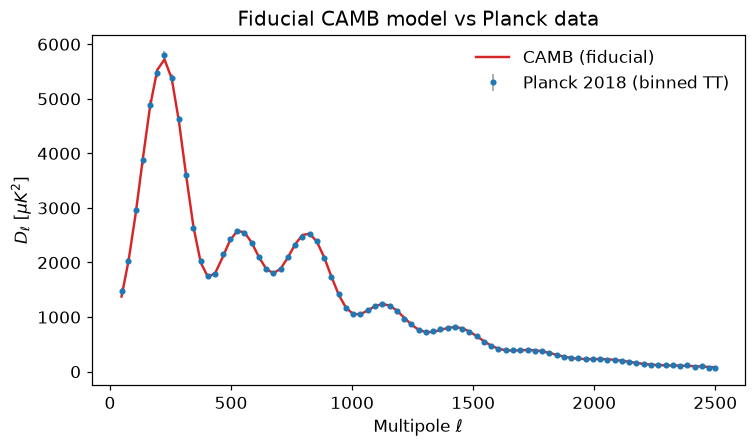

In [3]:
# Step 2: sanity check - theory at Planck 2018 fiducial values vs data
dl_fid = theory_dl(theta_fid)        # theta_fid = [ombh2, omch2, H0, tau, ln10As, ns]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(ell, Dl, yerr=err, fmt="o", ms=3, lw=1, color="C0",
            ecolor="0.6", label="Planck 2018 (binned TT)")
ax.plot(ell, dl_fid, "-", color="C3", lw=1.6, label="CAMB (fiducial)")
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell\ [\mu K^2]$")
ax.set_title("Fiducial CAMB model vs Planck data")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "theory_vs_data.pdf")); plt.show()

---
## Step 3 — Likelihood, priors and posterior
Defined in `planck_model.py`: a diagonal Gaussian likelihood
$\ln\mathcal{L}=-\tfrac12\sum_b (D_b-D_b^{\rm th})^2/\sigma_b^2$, flat priors on
five parameters, and a Gaussian prior $\tau\sim\mathcal{N}(0.0544,0.0073^2)$
(Planck lowE) that breaks the $A_s$–$\tau$ degeneracy. CAMB calls are wrapped in
`try/except` so extreme parameters return $-\infty$ instead of crashing a chain.

In [4]:
# Step 3: posterior is finite at the fiducial point
print("log-posterior at fiducial:", round(log_posterior(theta_fid), 2))

log-posterior at fiducial: -44.01


---
## Step 4 — MCMC sampling with `emcee`

Walkers start in a tight Gaussian ball around the fiducial point, run a short
burn-in, reset, then run the production phase; the chain is saved to `chains/`.

**Parallelisation.** Walker evaluations are parallelised with a process `Pool`
using the **`spawn`** start method: each worker imports `planck_model` fresh and
single-threaded. This is essential on this software stack — `fork` deadlocks
because NumPy's OpenBLAS and CAMB both use OpenMP, and forking an active OpenMP
runtime hangs. Progress is written to `chains/progress.log` so it can be
monitored from another cell (`!tail -n 8 chains/progress.log`) regardless of how
Jupyter streams stdout.

In [9]:
# Step 4: sampler configuration and walker initialisation
N_WALKERS = 16       # >= 2*NDIM
N_BURN    = 150      # burn-in steps (discarded)
N_PROD    = 1000     # production steps (kept)

INIT_STD = np.array([1e-4, 1e-3, 0.5, 0.002, 0.01, 0.005])   # per-parameter spread
rng = np.random.default_rng(42)
p0 = theta_fid + INIT_STD * rng.standard_normal((N_WALKERS, NDIM))
assert np.all([np.isfinite(log_posterior(p)) for p in p0]), "bad init"
print(f"{N_WALKERS} walkers x {N_BURN}+{N_PROD} steps initialised")

16 walkers x 150+1000 steps initialised


In [ ]:
# Step 4: run the sampler (parallel, spawn) and save the chain
import emcee, time
import multiprocessing as mp        # stdlib: planck_model funcs pickle by reference under spawn

USE_POOL = True
PROGRESS_FILE = os.path.join(CHAIN_DIR, "progress.log")

def _log(msg):
    """Print AND append to a file, so progress is visible even if Jupyter does
    not stream stdout live during a long cell."""
    line = f"{time.strftime('%H:%M:%S')}  {msg}"
    print(line, flush=True)
    with open(PROGRESS_FILE, "a") as f:
        f.write(line + "\n")

def run_sampler(pool=None):
    s = emcee.EnsembleSampler(N_WALKERS, NDIM, log_posterior, pool=pool)
    _log(f"start burn-in ({N_BURN} steps)")
    for i, _ in enumerate(s.sample(p0, iterations=N_BURN), 1):
        if i == 1 or i % 20 == 0:
            _log(f"burn-in {i}/{N_BURN}")
    state = s.get_last_sample(); s.reset()
    _log(f"start production ({N_PROD} steps)")
    for i, _ in enumerate(s.sample(state, iterations=N_PROD), 1):
        if i == 1 or i % 20 == 0:
            _log(f"prod {i}/{N_PROD}")
    return s

open(PROGRESS_FILE, "w").close()                       # reset the log
if USE_POOL:
    with mp.get_context("spawn").Pool() as pool:       # spawn: no OpenMP/fork deadlock
        sampler = run_sampler(pool)
else:
    sampler = run_sampler()

chain = sampler.get_chain()                            # (N_PROD, N_WALKERS, NDIM)
log_prob = sampler.get_log_prob()
np.save(os.path.join(CHAIN_DIR, "chain.npy"), chain)
np.save(os.path.join(CHAIN_DIR, "log_prob.npy"), log_prob)
print("mean acceptance fraction:",
      round(float(np.mean(sampler.acceptance_fraction)), 3))

12:03:54  start burn-in (150 steps)


---
## Next steps (to be filled)
- **Step 5** — Convergence diagnostics (autocorrelation, acceptance, traces).
- **Step 6** — Posteriors, credible intervals, best-fit overlay.
- **Step 7** — Model variations / robustness.